In [3]:
import random, math
from CriticalNodes import CriticalEdge, CriticalEdges
import pickle

import sys
sys.path.append('../')
from util import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Imports finished.")

Imports finished.


In [4]:
max_rate = 0.35
ptb_rate = [(i+1) * 0.05 for i in range(int(max_rate / 0.05))]

In [5]:
dataset = Dataset(root='/tmp/Cora', name='Cora', device=device)
data, in_feats, h_feats, num_classes = dataset.get_data()

gcn_model = get_model('../', in_feats, h_feats, num_classes, "cora", Models.GCN)
gcn_ground_truth, gcn_orig_pred = get_ground_truth(gcn_model, data, Models.GCN, testMask=False)
print(gcn_ground_truth)

gat_model = get_model('../', in_feats, h_feats, num_classes, "cora", Models.GAT)
gat_ground_truth, gat_orig_pred = get_ground_truth(gat_model, data, Models.GAT, testMask=False)
print(gat_ground_truth)

gsage_model = get_model('../', in_feats, h_feats, num_classes, "cora", Models.GSAGE)
gsage_ground_truth, gsage_orig_pred = get_ground_truth(gsage_model, data, Models.GSAGE, testMask=False)
print(gsage_ground_truth)

gsaint_model = get_model('../', in_feats, h_feats, num_classes, "cora", Models.GSAINT, data=dataset)
gsaint_ground_truth, gsaint_orig_pred = get_ground_truth(gsaint_model, data, Models.GSAINT, testMask=False)
print(gsaint_ground_truth)

0.7544313146233382
0.7603397341211225
0.5384047267355982
0.7699409158050221


In [6]:
def get_deg_diff(ce):
    deg_diffs = []
    for edge in ce.edges:
        deg_diffs.append(abs(edge.node1.degree - edge.node2.degree))
    
    return np.mean(deg_diffs)

def get_homo_diff(ce):
    homo_diffs = []
    for edge in ce.edges:
        homo_diffs.append(abs(edge.node1.homophily - edge.node2.homophily))
    
    return np.mean(homo_diffs)

def get_2hop_diff(ce):
    hop2_diffs = []
    for edge in ce.edges:
        hop2_diffs.append(abs(edge.node1.two_hop_neighborhood_size - edge.node2.two_hop_neighborhood_size))
    
    return np.mean(hop2_diffs)

In [7]:
def get_graph_diffs(G, edges):
    homophilies = [0] * len(edges)
    degrees = [0] * len(edges)
    two_hop_neighborhood_sizes = [0] * len(edges)
    
    i = 0
    for n in edges:
        homophilies[i] = abs(get_node_homophily(G, n[0], y, y[n[0]].item()) - get_node_homophily(G, n[1], y, y[n[1]].item()))
        degrees[i] = abs(G.degree(n[0]) - G.degree(n[1])) 
        two_hop_neighborhood_sizes[i] = abs(nx.ego_graph(G, n[0], 2).number_of_nodes() - nx.ego_graph(G, n[1], 2).number_of_nodes())
        i += 1
    
    homo_avg = np.mean(np.array(homophilies))
    degrees_avg = np.mean(np.array(degrees))
    hop2_avg = np.mean(np.array(two_hop_neighborhood_sizes))

    return homo_avg, degrees_avg, hop2_avg

In [8]:
### realistically, this should be the only function changing in your guys' notebooks
def checkCorrectClass(i, j, pred, labels):
    return pred[i].item() == pred[j].item() and labels[i].item() == labels[j].item() and pred[i].item() == labels[i].item() and pred[j].item() == labels[j].item()

In [9]:
# this will take a while to run (maybe about 5-10 minutes)
def get_edges(G, pred, labels):
    valid_adds = []
    tuples = set()
    
    for e in G.edges:
        i = e[0]
        j = e[1]
        # make sure not same node and that edge doesn't already exist (also check same classification! not same label)
        if (j, i) not in tuples and checkCorrectClass(i, j, pred, labels):
            valid_adds.append((i, j))
            tuples.add((i, j))

    return valid_adds

In [10]:
G, x, y, train_mask, test_mask = convert_to_networkx(data)

gcn_edges = get_edges(G, gcn_orig_pred, data.y)
gat_edges = get_edges(G, gat_orig_pred, data.y)
gsaint_edges = get_edges(G, gsaint_orig_pred, data.y)
gsage_edges = get_edges(G, gsage_orig_pred, data.y)

homo_gcn_diff, deg_gcn_diff, hop2_gcn_diff = get_graph_diffs(G, gcn_edges)
homo_gat_diff, deg_gat_diff, hop2_gat_diff = get_graph_diffs(G, gat_edges)
homo_gsaint_diff, deg_gsaint_diff, hop2_gsaint_diff = get_graph_diffs(G, gsaint_edges)
homo_gsage_diff, deg_gsage_diff, hop2_gsage_diff = get_graph_diffs(G, gsage_edges)

print(deg_gcn_diff)

32.006938421509105


In [11]:
base_directory = './critical-edges/degree-archs-15/'
types = ["gcn", "gat", "gsage", "gsaint"]

deg_gcn_inv = []
deg_gat_inv = []
deg_gsage_inv = []
deg_gsaint_inv = []

homo_gcn_inv = []
homo_gat_inv = []
homo_gsage_inv = []
homo_gsaint_inv = []

hop2_gcn_inv = []
hop2_gat_inv = []
hop2_gsage_inv = []
hop2_gsaint_inv = []

for type_dir in types:
    directory_path = os.path.join(base_directory, type_dir)
    
    files = sorted(os.listdir(directory_path))
    
    for file_name in files:
        if file_name.endswith('.pkl') and file_name.startswith('median_invalid'):
            file_path = os.path.join(directory_path, file_name)
            
            with open(file_path, 'rb') as file:
                pickle_object = pickle.load(file)
                if type_dir == "gcn":
                    deg_gcn_inv.append(get_deg_diff(pickle_object))
                    homo_gcn_inv.append(get_homo_diff(pickle_object))
                    hop2_gcn_inv.append(get_2hop_diff(pickle_object))
                if type_dir == "gat":
                    deg_gat_inv.append(get_deg_diff(pickle_object))
                    homo_gat_inv.append(get_homo_diff(pickle_object))
                    hop2_gat_inv.append(get_2hop_diff(pickle_object))
                if type_dir == "gsage":
                    deg_gsage_inv.append(get_deg_diff(pickle_object))
                    homo_gsage_inv.append(get_homo_diff(pickle_object))
                    hop2_gsage_inv.append(get_2hop_diff(pickle_object))
                if type_dir == "gsaint":
                    deg_gsaint_inv.append(get_deg_diff(pickle_object))
                    homo_gsaint_inv.append(get_homo_diff(pickle_object))
                    hop2_gsaint_inv.append(get_2hop_diff(pickle_object))


In [10]:
# print(deg_gcn)
# print(deg_gcn_diff)
# print(len(gcn_edges))
# print(G.number_of_edges() * 1/2)

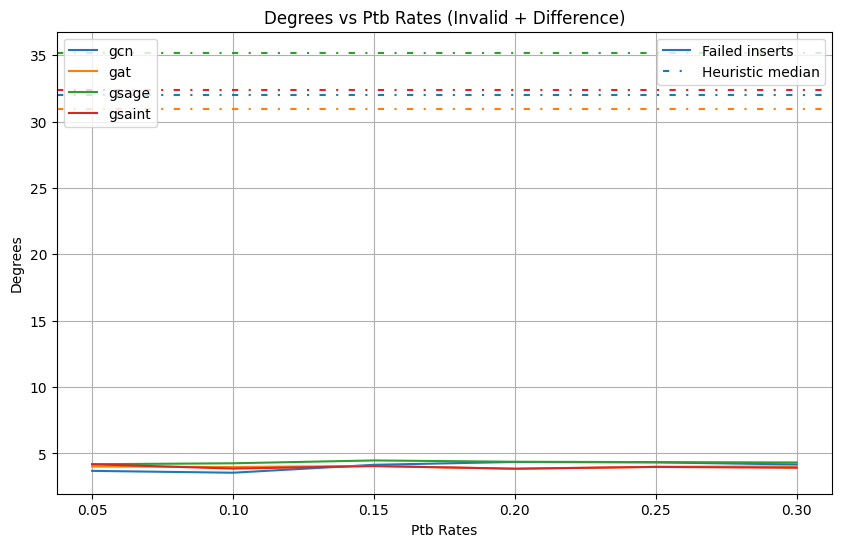

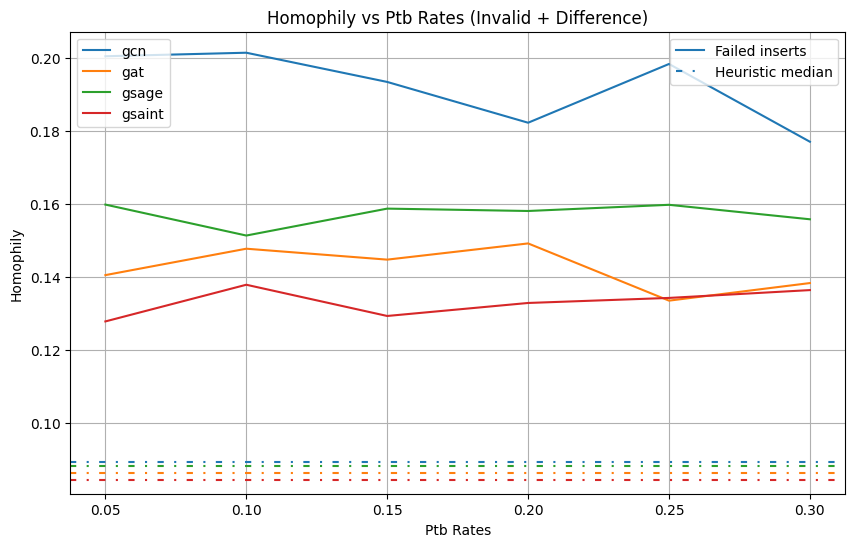

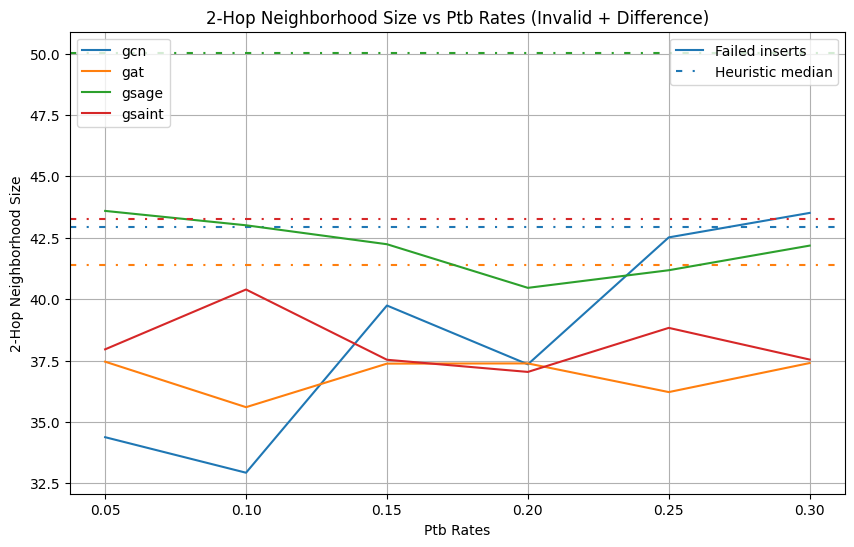

In [12]:
save_directory = './data/degree-archs-15/comparisons/'

def plot_and_save_graph(y_arrays, avg_values, y_label, title, filename):
    x = ptb_rate
    labels = ['gcn', 'gat', 'gsage', 'gsaint']
    plt.figure(figsize=(10, 6))
    
    lines = []
    avg_lines = []

    for y_array, avg_value, label in zip(y_arrays, avg_values, labels):
        line, = plt.plot(x, y_array, label=label)
        lines.append(line)
        avg_line = plt.axhline(y=avg_value, color=line.get_color(), linestyle=(0, (3, 5, 1, 5)))
        avg_lines.append(avg_line)

    plt.xlabel('Ptb Rates')
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True)
    
    # Create legends
    first_legend = plt.legend(lines, labels, loc='upper left')
    plt.gca().add_artist(first_legend)  # Add the first legend back

    second_legend = plt.legend([lines[0], avg_lines[0]], ['Failed inserts', 'Heuristic median'], loc='upper right')

    # Save the plot
    save_path = os.path.join(save_directory, filename)
    plt.savefig(save_path)
    plt.show()


plot_and_save_graph([deg_gcn_inv, deg_gat_inv, deg_gsage_inv, deg_gsaint_inv], [deg_gcn_diff, deg_gat_diff, deg_gsage_diff, deg_gsaint_diff], 'Degrees', 'Degrees vs Ptb Rates (Invalid + Difference)', 'inv_degrees_vs_ptb_rates_dif.png')
plot_and_save_graph([homo_gcn_inv, homo_gat_inv, homo_gsage_inv, homo_gsaint_inv], [homo_gcn_diff, homo_gat_diff, homo_gsage_diff, homo_gsaint_diff], 'Homophily', 'Homophily vs Ptb Rates (Invalid + Difference)', 'inv_homophily_vs_ptb_rates_dif.png')
plot_and_save_graph([hop2_gcn_inv, hop2_gat_inv, hop2_gsage_inv, hop2_gsaint_inv], [hop2_gcn_diff, hop2_gat_diff, hop2_gsage_diff, hop2_gsaint_diff], '2-Hop Neighborhood Size', '2-Hop Neighborhood Size vs Ptb Rates (Invalid + Difference)', 'inv_2hop_vs_ptb_rates_dif.png')

In [13]:
base_directory = './critical-edges/degree-archs-15/'
types = ["gcn", "gat", "gsage", "gsaint"]

deg_gcn_val = []
deg_gat_val = []
deg_gsage_val = []
deg_gsaint_val = []

homo_gcn_val = []
homo_gat_val = []
homo_gsage_val = []
homo_gsaint_val = []

hop2_gcn_val = []
hop2_gat_val = []
hop2_gsage_val = []
hop2_gsaint_val = []

for type_dir in types:
    directory_path = os.path.join(base_directory, type_dir)
    
    files = sorted(os.listdir(directory_path))
    
    for file_name in files:
        if file_name.endswith('.pkl') and file_name.startswith('median_valid'):
            file_path = os.path.join(directory_path, file_name)
            
            with open(file_path, 'rb') as file:
                pickle_object = pickle.load(file)
                if type_dir == "gcn":
                    deg_gcn_val.append(get_deg_diff(pickle_object))
                    homo_gcn_val.append(get_homo_diff(pickle_object))
                    hop2_gcn_val.append(get_2hop_diff(pickle_object))
                if type_dir == "gat":
                    deg_gat_val.append(get_deg_diff(pickle_object))
                    homo_gat_val.append(get_homo_diff(pickle_object))
                    hop2_gat_val.append(get_2hop_diff(pickle_object))
                if type_dir == "gsage":
                    deg_gsage_val.append(get_deg_diff(pickle_object))
                    homo_gsage_val.append(get_homo_diff(pickle_object))
                    hop2_gsage_val.append(get_2hop_diff(pickle_object))
                if type_dir == "gsaint":
                    deg_gsaint_val.append(get_deg_diff(pickle_object))
                    homo_gsaint_val.append(get_homo_diff(pickle_object))
                    hop2_gsaint_val.append(get_2hop_diff(pickle_object))

print(deg_gcn_val)

[3.8200253485424587, 4.2530044275774825, 4.058997050147493, 3.9949447077409164, 4.0171847359110435, 4.002105706464519]


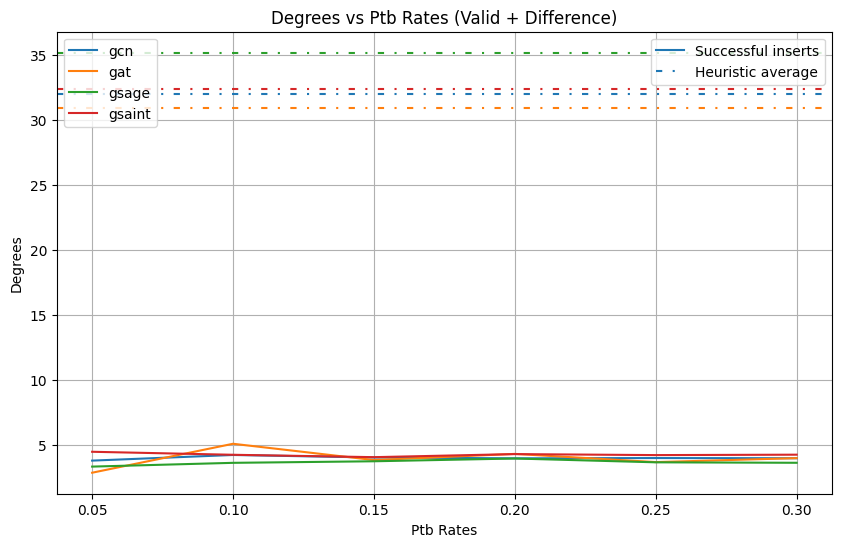

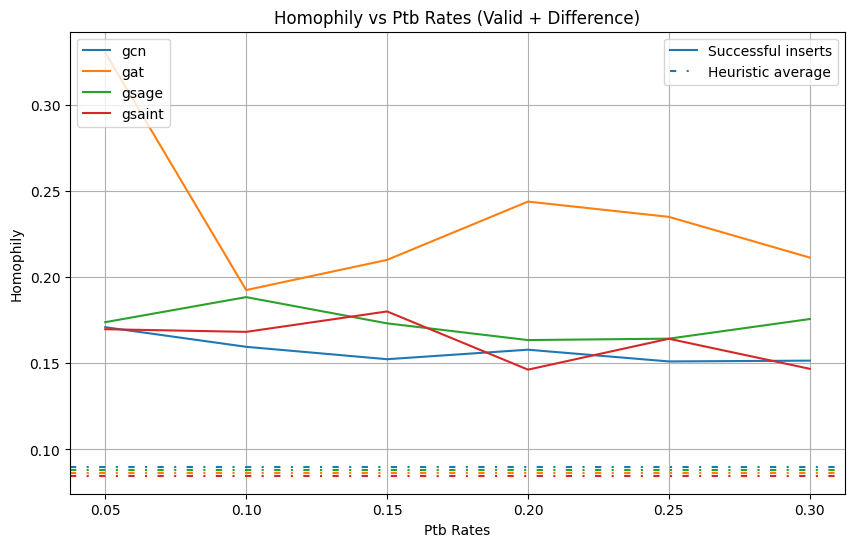

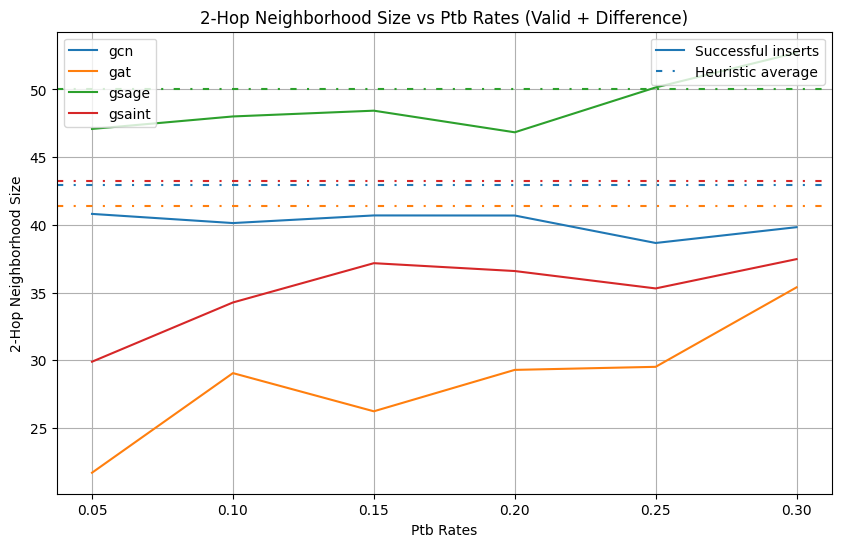

In [14]:
save_directory = './data/degree-archs-15/comparisons/'

def plot_and_save_graph(y_arrays, avg_values, y_label, title, filename):
    x = ptb_rate
    labels = ['gcn', 'gat', 'gsage', 'gsaint']
    plt.figure(figsize=(10, 6))
    
    lines = []
    avg_lines = []

    for y_array, avg_value, label in zip(y_arrays, avg_values, labels):
        line, = plt.plot(x, y_array, label=label)
        lines.append(line)
        avg_line = plt.axhline(y=avg_value, color=line.get_color(), linestyle=(0, (3, 5, 1, 5)))
        avg_lines.append(avg_line)

    plt.xlabel('Ptb Rates')
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True)
    
    # Create legends
    first_legend = plt.legend(lines, labels, loc='upper left')
    plt.gca().add_artist(first_legend)  # Add the first legend back

    second_legend = plt.legend([lines[0], avg_lines[0]], ['Successful inserts', 'Heuristic average'], loc='upper right')

    # Save the plot
    save_path = os.path.join(save_directory, filename)
    plt.savefig(save_path)
    plt.show()


plot_and_save_graph([deg_gcn_val, deg_gat_val, deg_gsage_val, deg_gsaint_val], [deg_gcn_diff, deg_gat_diff, deg_gsage_diff, deg_gsaint_diff], 'Degrees', 'Degrees vs Ptb Rates (Valid + Difference)', 'val_degrees_vs_ptb_rates_dif.png')
plot_and_save_graph([homo_gcn_val, homo_gat_val, homo_gsage_val, homo_gsaint_val], [homo_gcn_diff, homo_gat_diff, homo_gsage_diff, homo_gsaint_diff], 'Homophily', 'Homophily vs Ptb Rates (Valid + Difference)', 'val_homophily_vs_ptb_rates_dif.png')
plot_and_save_graph([hop2_gcn_val, hop2_gat_val, hop2_gsage_val, hop2_gsaint_val], [hop2_gcn_diff, hop2_gat_diff, hop2_gsage_diff, hop2_gsaint_diff], '2-Hop Neighborhood Size', '2-Hop Neighborhood Size vs Ptb Rates (Valid + Difference)', 'val_2hop_vs_ptb_rates_dif.png')

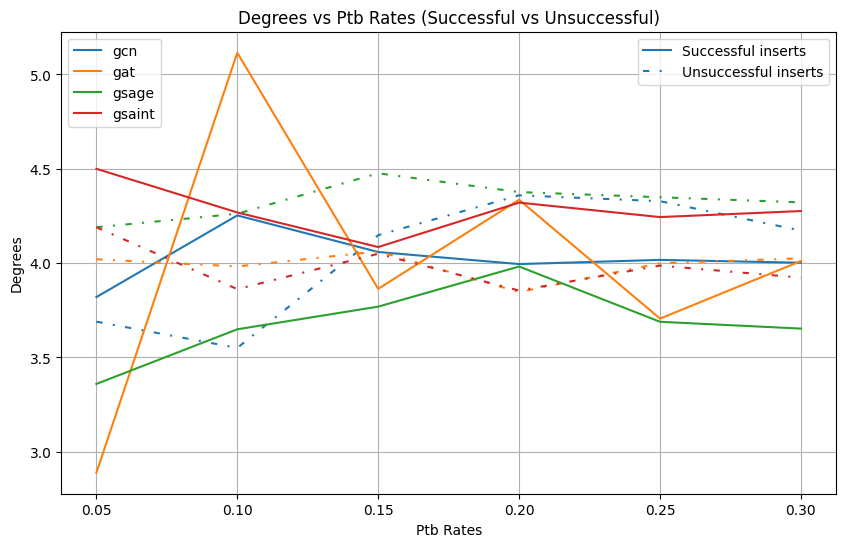

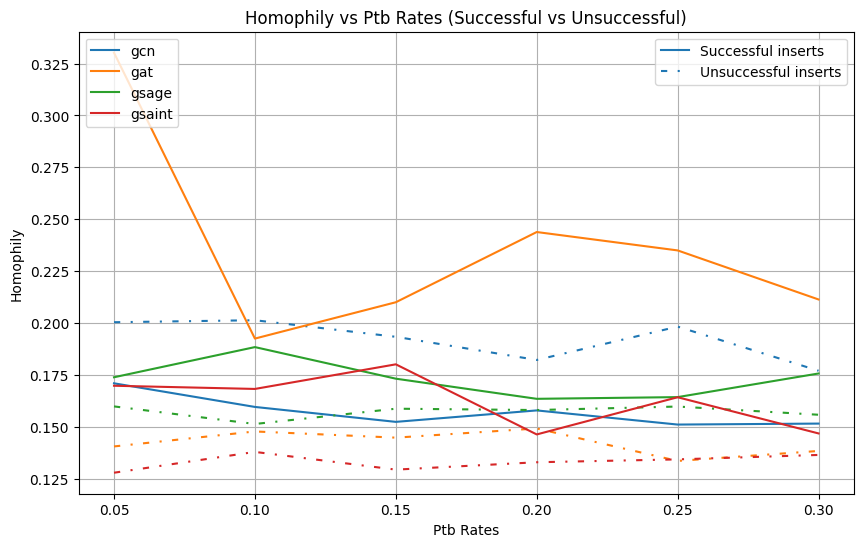

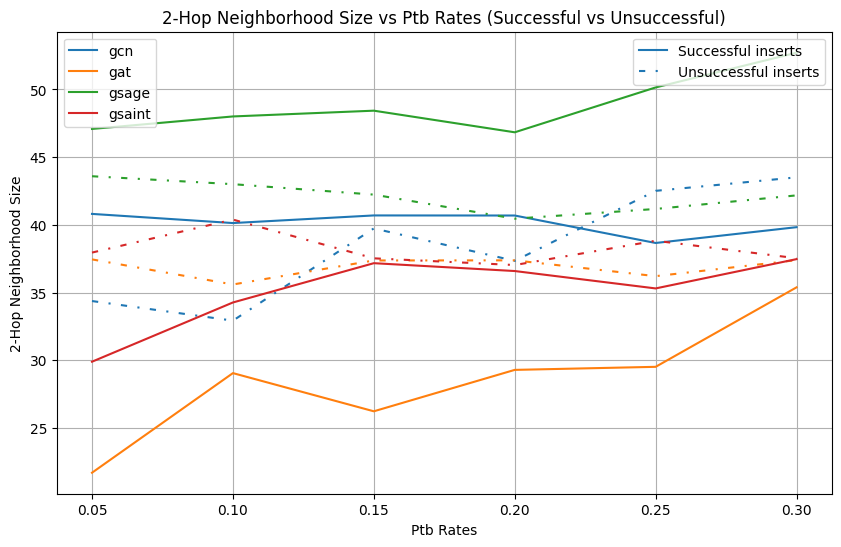

In [15]:
save_directory = './data/degree-archs-15/comparisons/'

def plot_and_save_graph(y_arrays, avg_values, y_label, title, filename):
    x = ptb_rate
    labels = ['gcn', 'gat', 'gsage', 'gsaint']
    plt.figure(figsize=(10, 6))
    
    lines = []
    avg_lines = []

    for y_array, avg_value, label in zip(y_arrays, avg_values, labels):
        line, = plt.plot(x, y_array, label=label)
        lines.append(line)
        avg_line, = plt.plot(x, avg_value, color=line.get_color(), linestyle=(0, (3, 5, 1, 5)), label=f'{label} unsuccessful inserts')
        avg_lines.append(avg_line)

    plt.xlabel('Ptb Rates')
    plt.ylabel(y_label)
    plt.title(title)
    plt.grid(True)
    
    # Create legends
    first_legend = plt.legend(lines, labels, loc='upper left')
    plt.gca().add_artist(first_legend)  # Add the first legend back

    second_legend = plt.legend([lines[0], avg_lines[0]], ['Successful inserts', 'Unsuccessful inserts'], loc='upper right')

    # Save the plot
    save_path = os.path.join(save_directory, filename)
    plt.savefig(save_path)
    plt.show()

plot_and_save_graph([deg_gcn_val, deg_gat_val, deg_gsage_val, deg_gsaint_val], [deg_gcn_inv, deg_gat_inv, deg_gsage_inv, deg_gsaint_inv], 'Degrees', 'Degrees vs Ptb Rates (Successful vs Unsuccessful)', 'val_degrees_vs_ptb_rates_dif.png')
plot_and_save_graph([homo_gcn_val, homo_gat_val, homo_gsage_val, homo_gsaint_val], [homo_gcn_inv, homo_gat_inv, homo_gsage_inv, homo_gsaint_inv], 'Homophily', 'Homophily vs Ptb Rates (Successful vs Unsuccessful)', 'val_homophily_vs_ptb_rates_dif.png')
plot_and_save_graph([hop2_gcn_val, hop2_gat_val, hop2_gsage_val, hop2_gsaint_val], [hop2_gcn_inv, hop2_gat_inv, hop2_gsage_inv, hop2_gsaint_inv], '2-Hop Neighborhood Size', '2-Hop Neighborhood Size vs Ptb Rates (Successful vs Unsuccessful)', 'val_2hop_vs_ptb_rates_dif.png')